# Analysis: F1 — computeLikelihoodFromBuffer for OpenACC

**Comparison of:** `2026_03_16_bl_estimation_buffer` (B1 baseline) vs `2026_03_16_bl_estimation_fused` (F1: fused likelihood from buffer)  
**Dataset:** 100 taxa, 1M sites, 10 different trees, 10 runs each  
**Backend:** OPENACC (GPU V100)  
**Models:** DNA/GTR unrooted, AA/LG unrooted  

**Change:** Eliminated redundant full likelihood evaluations during branch length optimization.  
- `computeLikelihoodFromBufferPointer` was `NULL` for OpenACC — every convergence check (~197/round) called the **full** `computeLikelihoodBranchGenericOpenACC`  
- F1: derivative kernel now stores `_pattern_lh[p]` as a side-effect; new `computeLikelihoodFromBufferOpenACC()` does a cheap GPU reduction  
- Eliminates ~600-800 redundant full likelihood evaluations per optimization

In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cwd = os.getcwd()
baseline_path = "/Users/u7826985/Projects/Nvidia/results/2026_03_16_bl_estimation_buffer"
f1_path = "/Users/u7826985/Projects/Nvidia/results/2026_03_16_bl_estimation_fused"

# 1. Parse all log files

In [2]:
alignment_pattern = re.compile(r"Alignment has (\d+) sequences with (\d+) columns, (\d+) distinct patterns")
initial_ll_pattern = re.compile(r"Initial log-likelihood:\s+([-0-9.]+)")
optimal_ll_pattern = re.compile(r"Optimal log-likelihood:\s+([-0-9.]+)")
params_opt_pattern = re.compile(r"Parameters optimization took (\d+) rounds? \(([0-9.]+) sec\)")
wallclock_pattern = re.compile(r"Total wall-clock time used:\s+([0-9.]+)\s+sec")

In [3]:
def parse_all_logs(results_path, source_label="baseline"):
    """Parse all IQ-TREE log files and extract timing/likelihood data."""
    rows = []
    skipped = 0

    for data_type in ['AA', 'DNA']:
        data_dir = os.path.join(results_path, data_type)
        if not os.path.exists(data_dir):
            continue

        for tree_type in ['rooted', 'unrooted']:
            tree_type_dir = os.path.join(data_dir, tree_type)
            if not os.path.exists(tree_type_dir):
                continue

            for model in sorted(os.listdir(tree_type_dir)):
                model_dir = os.path.join(tree_type_dir, model)
                if not os.path.isdir(model_dir):
                    continue

                for tree_folder in sorted(os.listdir(model_dir)):
                    tree_dir = os.path.join(model_dir, tree_folder)
                    if not os.path.isdir(tree_dir):
                        continue

                    for fname in os.listdir(tree_dir):
                        if not fname.endswith('.log'):
                            continue

                        filepath = os.path.join(tree_dir, fname)
                        with open(filepath, 'r') as f:
                            content = f.read()

                        if 'OPENACC' in fname:
                            backend = 'GPU_V100'
                        elif 'OMP_48' in fname:
                            backend = 'CPU_48cores'
                        elif 'OMP_10' in fname:
                            backend = 'CPU_10cores'
                        elif 'VANILA' in fname:
                            backend = 'CPU_1core'
                        else:
                            continue

                        run_matches = re.findall(r'_run(\d+)_', fname)
                        run_number = int(run_matches[-1]) if run_matches else None

                        aln_match = alignment_pattern.search(content)
                        init_ll_match = initial_ll_pattern.search(content)
                        opt_ll_match = optimal_ll_pattern.search(content)
                        opt_match = params_opt_pattern.search(content)
                        wc_match = wallclock_pattern.search(content)

                        if aln_match and init_ll_match and opt_match and wc_match:
                            rows.append({
                                'source': source_label,
                                'data_type': data_type,
                                'tree_type': tree_type,
                                'model': model,
                                'treefile': tree_folder,
                                'backend': backend,
                                'run': run_number,
                                'taxa': int(aln_match.group(1)),
                                'sites': int(aln_match.group(2)),
                                'patterns': int(aln_match.group(3)),
                                'initial_likelihood': float(init_ll_match.group(1)),
                                'optimal_likelihood': float(opt_ll_match.group(1)) if opt_ll_match else float(init_ll_match.group(1)),
                                'opt_rounds': int(opt_match.group(1)),
                                'opt_time': float(opt_match.group(2)),
                                'wallclock_time': float(wc_match.group(1)),
                            })
                        else:
                            skipped += 1

    df = pd.DataFrame(rows)
    print(f"[{source_label}] Parsed {len(df)} log files ({skipped} skipped)")
    return df

df_baseline = parse_all_logs(baseline_path, "B1 (baseline)")
df_f1 = parse_all_logs(f1_path, "F1 (fused)")

[B1 (baseline)] Parsed 200 log files (0 skipped)


[F1 (fused)] Parsed 200 log files (0 skipped)


# 2. Data overview

In [4]:
print("=== B1 (baseline) data breakdown ===")
print(df_baseline.groupby(['data_type','tree_type','model','backend']).size().reset_index(name='count'))
print(f"\n=== F1 (fused) data breakdown ===")
print(df_f1.groupby(['data_type','tree_type','model','backend']).size().reset_index(name='count'))

# Combine
df_all = pd.concat([df_baseline, df_f1], ignore_index=True)
df_all['combo'] = df_all['data_type'] + '\n' + df_all['model'] + '\n' + df_all['tree_type']

=== B1 (baseline) data breakdown ===
  data_type tree_type model   backend  count
0        AA  unrooted    LG  GPU_V100    100
1       DNA  unrooted   GTR  GPU_V100    100

=== F1 (fused) data breakdown ===
  data_type tree_type model   backend  count
0        AA  unrooted    LG  GPU_V100    100
1       DNA  unrooted   GTR  GPU_V100    100


# 3. Statistical comparison

In [5]:
print("=" * 80)
print("COMPARISON: B1 (baseline) vs F1 (computeLikelihoodFromBuffer for OpenACC)")
print("  B1 = computeLikelihoodFromBufferPointer = NULL (full eval per convergence check)")
print("  F1 = derivative kernel stores _pattern_lh; cheap GPU reduction for fromBuffer")
print("=" * 80)

combos = df_f1[['data_type','tree_type','model','backend']].drop_duplicates()

for _, combo in combos.iterrows():
    dt, tt, model, backend = combo['data_type'], combo['tree_type'], combo['model'], combo['backend']
    bl_sub = df_baseline[(df_baseline['data_type']==dt) & (df_baseline['tree_type']==tt) & 
                   (df_baseline['model']==model) & (df_baseline['backend']==backend)]
    f1_sub = df_f1[(df_f1['data_type']==dt) & (df_f1['tree_type']==tt) & 
                   (df_f1['model']==model) & (df_f1['backend']==backend)]
    
    print(f"\n--- {dt} | {tt} | {model} | {backend} ---")
    print(f"  B1:  n={len(bl_sub)}, wallclock median={bl_sub['wallclock_time'].median():.3f}s, "
          f"mean={bl_sub['wallclock_time'].mean():.3f}s, std={bl_sub['wallclock_time'].std():.3f}s")
    print(f"  F1:  n={len(f1_sub)}, wallclock median={f1_sub['wallclock_time'].median():.3f}s, "
          f"mean={f1_sub['wallclock_time'].mean():.3f}s, std={f1_sub['wallclock_time'].std():.3f}s")
    if bl_sub['wallclock_time'].median() > 0:
        pct = (f1_sub['wallclock_time'].median() - bl_sub['wallclock_time'].median()) / bl_sub['wallclock_time'].median() * 100
        print(f"  Wallclock change (median): {pct:+.2f}%")
    
    # opt_time comparison
    if len(bl_sub) > 0 and 'opt_time' in bl_sub.columns:
        print(f"  B1 opt_time: median={bl_sub['opt_time'].median():.3f}s, mean={bl_sub['opt_time'].mean():.3f}s")
        print(f"  F1 opt_time: median={f1_sub['opt_time'].median():.3f}s, mean={f1_sub['opt_time'].mean():.3f}s")
        pct2 = (f1_sub['opt_time'].median() - bl_sub['opt_time'].median()) / bl_sub['opt_time'].median() * 100
        print(f"  Opt_time change (median): {pct2:+.2f}%")
    
    # LL comparison
    print(f"  B1 optimal_LL: {sorted(bl_sub['optimal_likelihood'].unique())}")
    print(f"  F1 optimal_LL: {sorted(f1_sub['optimal_likelihood'].unique())}")
    bl_lls = set(bl_sub['optimal_likelihood'].unique())
    f1_lls = set(f1_sub['optimal_likelihood'].unique())
    if bl_lls == f1_lls:
        print(f"  LL match: YES (exact match)")
    else:
        # Check max diff
        bl_sorted = sorted(bl_sub['optimal_likelihood'].unique())
        f1_sorted = sorted(f1_sub['optimal_likelihood'].unique())
        if len(bl_sorted) == len(f1_sorted):
            max_diff = max(abs(a - b) for a, b in zip(bl_sorted, f1_sorted))
            print(f"  LL match: NO — max diff = {max_diff:.6f}")
        else:
            print(f"  LL match: NO — different number of unique values!")

COMPARISON: B1 (baseline) vs F1 (computeLikelihoodFromBuffer for OpenACC)
  B1 = computeLikelihoodFromBufferPointer = NULL (full eval per convergence check)
  F1 = derivative kernel stores _pattern_lh; cheap GPU reduction for fromBuffer

--- AA | unrooted | LG | GPU_V100 ---
  B1:  n=100, wallclock median=18.239s, mean=17.652s, std=1.304s
  F1:  n=100, wallclock median=18.697s, mean=18.101s, std=1.342s
  Wallclock change (median): +2.51%
  B1 opt_time: median=15.388s, mean=14.790s
  F1 opt_time: median=15.838s, mean=15.237s
  Opt_time change (median): +2.93%
  B1 optimal_LL: [-90504713.177, -88901422.374, -87712627.079, -87357001.171, -87134163.126, -86714228.485, -86382770.364, -84301496.968, -82340194.25, -81931521.002]
  F1 optimal_LL: [-90504713.177, -88901422.374, -87712627.079, -87357001.171, -87134163.126, -86714228.485, -86382770.364, -84301496.968, -82340194.25, -81931521.002]
  LL match: YES (exact match)

--- DNA | unrooted | GTR | GPU_V100 ---
  B1:  n=100, wallclock median

# 4. Plot setup

In [6]:
SOURCE_PALETTE = {'B1 (baseline)': '#1565C0', 'F1 (fused)': '#2E7D32'}

sns.set_style("whitegrid")
sns.set_context("talk")
plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300, 'font.size': 13,
    'axes.titlesize': 14, 'axes.labelsize': 13,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'legend.fontsize': 11, 'figure.titlesize': 16,
    'axes.linewidth': 1.2, 'lines.linewidth': 2,
    'savefig.bbox': 'tight', 'savefig.pad_inches': 0.15,
    'figure.facecolor': 'white', 'savefig.facecolor': 'white',
    'font.family': 'sans-serif',
})

# 5. Wall-clock time per tree

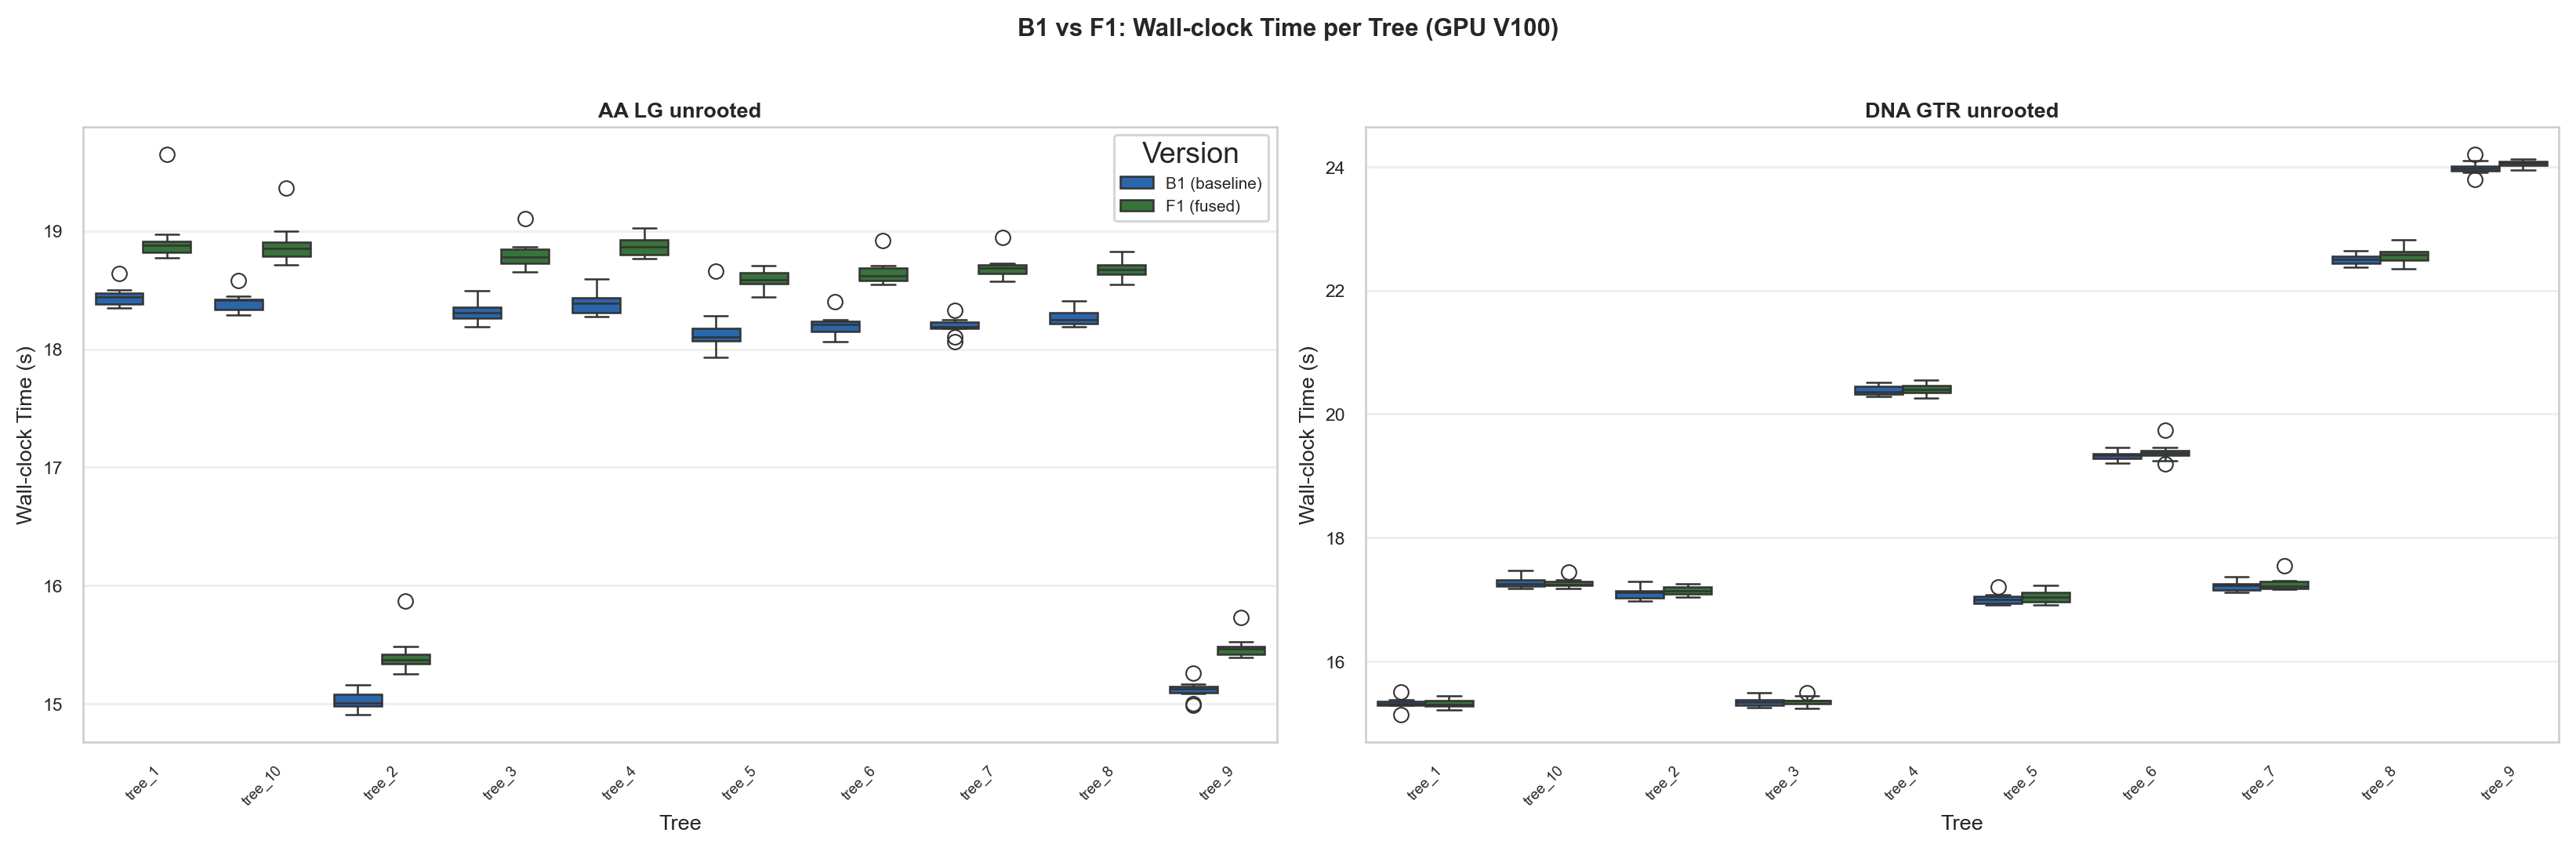

In [7]:
combos = df_f1[['data_type','tree_type','model']].drop_duplicates()
n_combos = len(combos)
fig, axes = plt.subplots(1, n_combos, figsize=(11 * n_combos, 7))
if n_combos == 1:
    axes = [axes]

for idx, (_, combo) in enumerate(combos.iterrows()):
    dt, tt, model = combo['data_type'], combo['tree_type'], combo['model']
    subset = df_all[(df_all['data_type']==dt) & (df_all['tree_type']==tt) & (df_all['model']==model)]
    ax = axes[idx]
    sns.boxplot(data=subset, x='treefile', y='wallclock_time', hue='source',
                hue_order=['B1 (baseline)', 'F1 (fused)'], palette=SOURCE_PALETTE,
                linewidth=1.2, ax=ax)
    ax.set_title(f'{dt} {model} {tt}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Tree')
    ax.set_ylabel('Wall-clock Time (s)')
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.grid(True, axis='y', alpha=0.3)
    if idx > 0:
        ax.get_legend().remove()
    else:
        ax.legend(title='Version', fontsize=10)

plt.suptitle('B1 vs F1: Wall-clock Time per Tree (GPU V100)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{cwd}/comparison_wallclock_per_tree.png", bbox_inches='tight', dpi=300)
plt.show()

# 6. Optimization time per tree (opt_time is the key metric)

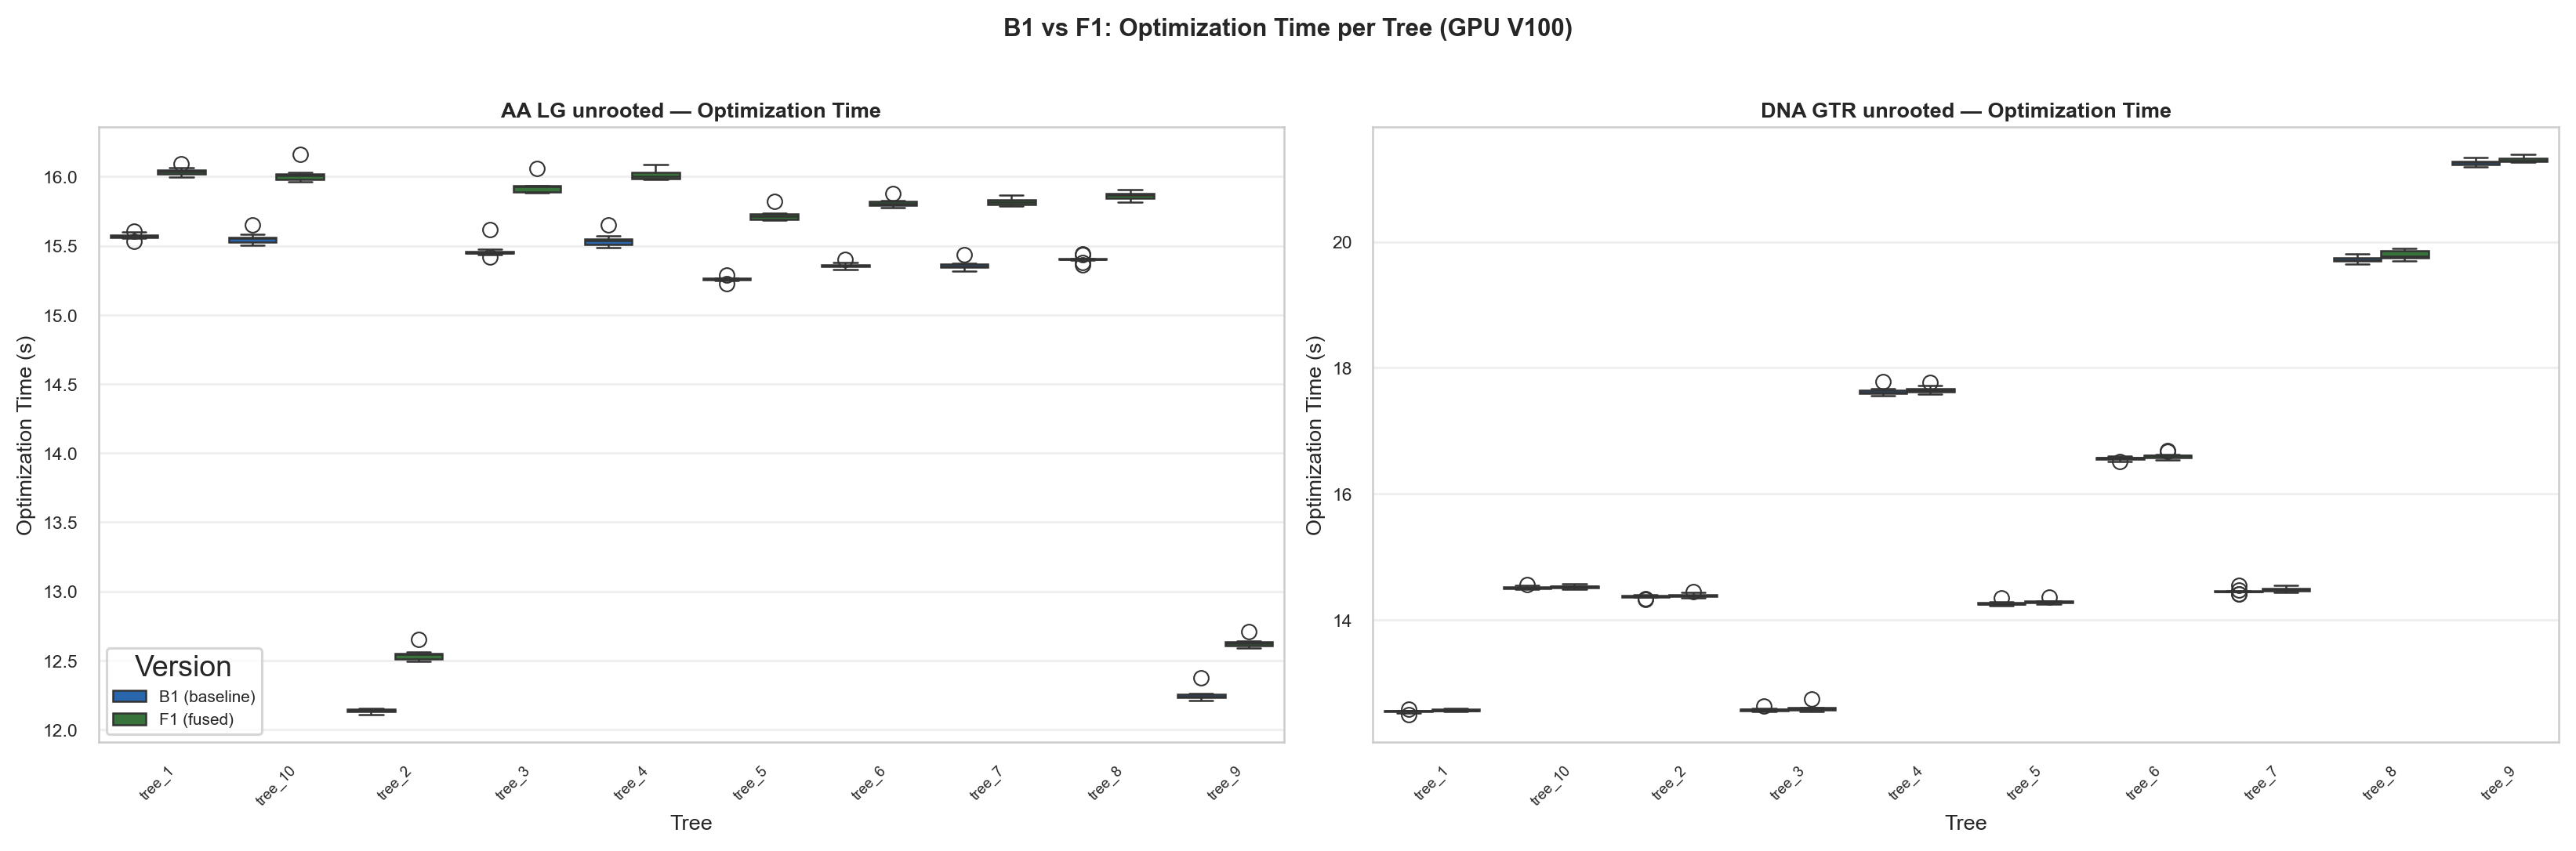

In [8]:
combos = df_f1[['data_type','tree_type','model']].drop_duplicates()
n_combos = len(combos)
fig, axes = plt.subplots(1, n_combos, figsize=(11 * n_combos, 7))
if n_combos == 1:
    axes = [axes]

for idx, (_, combo) in enumerate(combos.iterrows()):
    dt, tt, model = combo['data_type'], combo['tree_type'], combo['model']
    subset = df_all[(df_all['data_type']==dt) & (df_all['tree_type']==tt) & (df_all['model']==model)]
    ax = axes[idx]
    sns.boxplot(data=subset, x='treefile', y='opt_time', hue='source',
                hue_order=['B1 (baseline)', 'F1 (fused)'], palette=SOURCE_PALETTE,
                linewidth=1.2, ax=ax)
    ax.set_title(f'{dt} {model} {tt} — Optimization Time', fontsize=13, fontweight='bold')
    ax.set_xlabel('Tree')
    ax.set_ylabel('Optimization Time (s)')
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.grid(True, axis='y', alpha=0.3)
    if idx > 0:
        ax.get_legend().remove()
    else:
        ax.legend(title='Version', fontsize=10)

plt.suptitle('B1 vs F1: Optimization Time per Tree (GPU V100)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{cwd}/comparison_opt_time_per_tree.png", bbox_inches='tight', dpi=300)
plt.show()

# 7. Aggregated comparison (wallclock + opt_time)

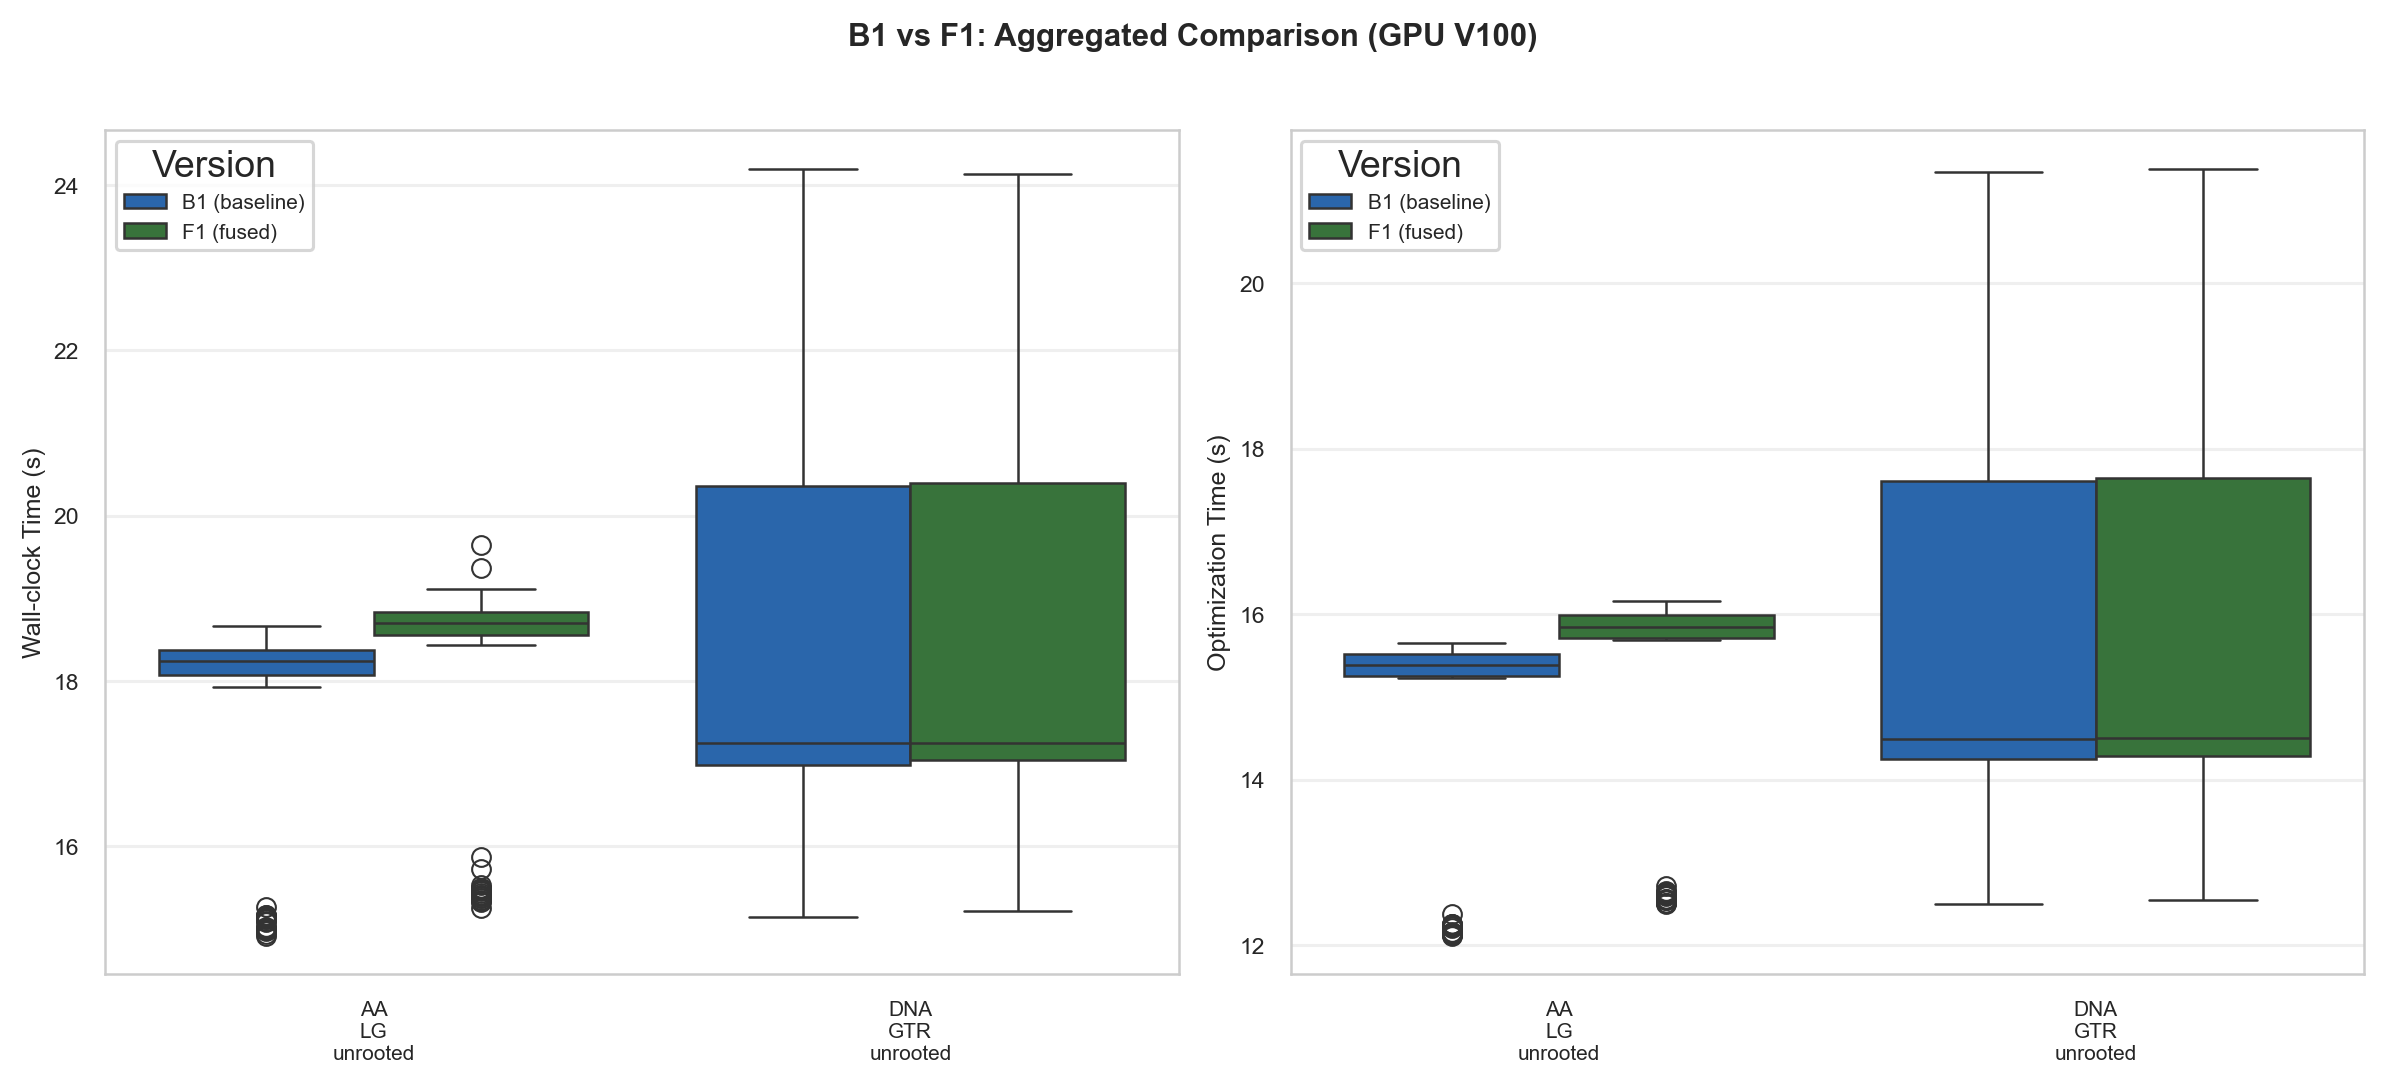

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

for ax, metric, label in [(ax1, 'wallclock_time', 'Wall-clock Time (s)'), 
                           (ax2, 'opt_time', 'Optimization Time (s)')]:
    sns.boxplot(data=df_all, x='combo', y=metric, hue='source',
                hue_order=['B1 (baseline)', 'F1 (fused)'], palette=SOURCE_PALETTE,
                linewidth=1.2, ax=ax)
    ax.set_xlabel('')
    ax.set_ylabel(label, fontsize=12)
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend(title='Version', fontsize=10)
    ax.tick_params(axis='x', labelsize=10)

plt.suptitle('B1 vs F1: Aggregated Comparison (GPU V100)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{cwd}/comparison_aggregated.png", bbox_inches='tight', dpi=300)
plt.show()

# 8. Per-tree median comparison table

In [10]:
combos = df_f1[['data_type','tree_type','model','backend']].drop_duplicates()

for _, combo in combos.iterrows():
    dt, tt, model, backend = combo['data_type'], combo['tree_type'], combo['model'], combo['backend']
    print(f"\n{'='*80}")
    print(f"  {dt}/{model} ({tt}) — {backend}")
    print(f"{'='*80}")
    print(f"{'Tree':<10} {'B1 wc_med':>12} {'F1 wc_med':>12} {'Diff (s)':>10} {'Change':>10} | {'B1 opt_med':>12} {'F1 opt_med':>12} {'Opt chg':>10} {'LL match':>10}")
    print(f"{'-'*10} {'-'*12} {'-'*12} {'-'*10} {'-'*10} | {'-'*12} {'-'*12} {'-'*10} {'-'*10}")

    all_bl_wc = []
    all_f1_wc = []
    all_bl_opt = []
    all_f1_opt = []

    trees = sorted(set(df_baseline[(df_baseline['data_type']==dt) & (df_baseline['model']==model)]['treefile'].unique()) |
                   set(df_f1[(df_f1['data_type']==dt) & (df_f1['model']==model)]['treefile'].unique()))

    for tree in trees:
        bl_wc = df_baseline[(df_baseline['data_type']==dt) & (df_baseline['tree_type']==tt) & 
                         (df_baseline['model']==model) & (df_baseline['treefile']==tree) &
                         (df_baseline['backend']==backend)]['wallclock_time']
        f1_wc = df_f1[(df_f1['data_type']==dt) & (df_f1['tree_type']==tt) & 
                         (df_f1['model']==model) & (df_f1['treefile']==tree) &
                         (df_f1['backend']==backend)]['wallclock_time']
        bl_opt = df_baseline[(df_baseline['data_type']==dt) & (df_baseline['tree_type']==tt) & 
                         (df_baseline['model']==model) & (df_baseline['treefile']==tree) &
                         (df_baseline['backend']==backend)]['opt_time']
        f1_opt = df_f1[(df_f1['data_type']==dt) & (df_f1['tree_type']==tt) & 
                         (df_f1['model']==model) & (df_f1['treefile']==tree) &
                         (df_f1['backend']==backend)]['opt_time']
        bl_lls = df_baseline[(df_baseline['data_type']==dt) & (df_baseline['tree_type']==tt) & 
                       (df_baseline['model']==model) & (df_baseline['treefile']==tree) &
                       (df_baseline['backend']==backend)]['optimal_likelihood']
        f1_lls = df_f1[(df_f1['data_type']==dt) & (df_f1['tree_type']==tt) & 
                       (df_f1['model']==model) & (df_f1['treefile']==tree) &
                       (df_f1['backend']==backend)]['optimal_likelihood']

        if len(bl_wc) == 0 or len(f1_wc) == 0:
            continue

        bl_wc_med = bl_wc.median()
        f1_wc_med = f1_wc.median()
        bl_opt_med = bl_opt.median()
        f1_opt_med = f1_opt.median()
        diff = f1_wc_med - bl_wc_med
        pct = (diff / bl_wc_med) * 100
        opt_pct = (f1_opt_med - bl_opt_med) / bl_opt_med * 100
        ll_match = "YES" if set(bl_lls.unique()) == set(f1_lls.unique()) else "NO"

        all_bl_wc.append(bl_wc_med)
        all_f1_wc.append(f1_wc_med)
        all_bl_opt.append(bl_opt_med)
        all_f1_opt.append(f1_opt_med)

        print(f"{tree:<10} {bl_wc_med:>12.3f} {f1_wc_med:>12.3f} {diff:>+10.3f} {pct:>+9.1f}% | {bl_opt_med:>12.3f} {f1_opt_med:>12.3f} {opt_pct:>+9.1f}% {ll_match:>10}")

    if all_bl_wc and all_f1_wc:
        avg_bl = np.mean(all_bl_wc)
        avg_f1 = np.mean(all_f1_wc)
        avg_bl_opt = np.mean(all_bl_opt)
        avg_f1_opt = np.mean(all_f1_opt)
        print(f"{'-'*10} {'-'*12} {'-'*12} {'-'*10} {'-'*10} | {'-'*12} {'-'*12} {'-'*10} {'-'*10}")
        print(f"{'MEAN':<10} {avg_bl:>12.3f} {avg_f1:>12.3f} {avg_f1-avg_bl:>+10.3f} {(avg_f1-avg_bl)/avg_bl*100:>+9.1f}% | {avg_bl_opt:>12.3f} {avg_f1_opt:>12.3f} {(avg_f1_opt-avg_bl_opt)/avg_bl_opt*100:>+9.1f}%")


  AA/LG (unrooted) — GPU_V100
Tree          B1 wc_med    F1 wc_med   Diff (s)     Change |   B1 opt_med   F1 opt_med    Opt chg   LL match
---------- ------------ ------------ ---------- ---------- | ------------ ------------ ---------- ----------
tree_1           18.443       18.878     +0.435      +2.4% |       15.564       16.035      +3.0%        YES
tree_10          18.416       18.850     +0.434      +2.4% |       15.555       16.006      +2.9%        YES
tree_2           15.011       15.373     +0.363      +2.4% |       12.143       12.543      +3.3%        YES
tree_3           18.312       18.781     +0.469      +2.6% |       15.448       15.928      +3.1%        YES
tree_4           18.389       18.867     +0.478      +2.6% |       15.535       16.001      +3.0%        YES
tree_5           18.104       18.586     +0.482      +2.7% |       15.258       15.715      +3.0%        YES
tree_6           18.208       18.620     +0.412      +2.3% |       15.355       15.805      +2.9%

# 9. Per-run speedup distribution

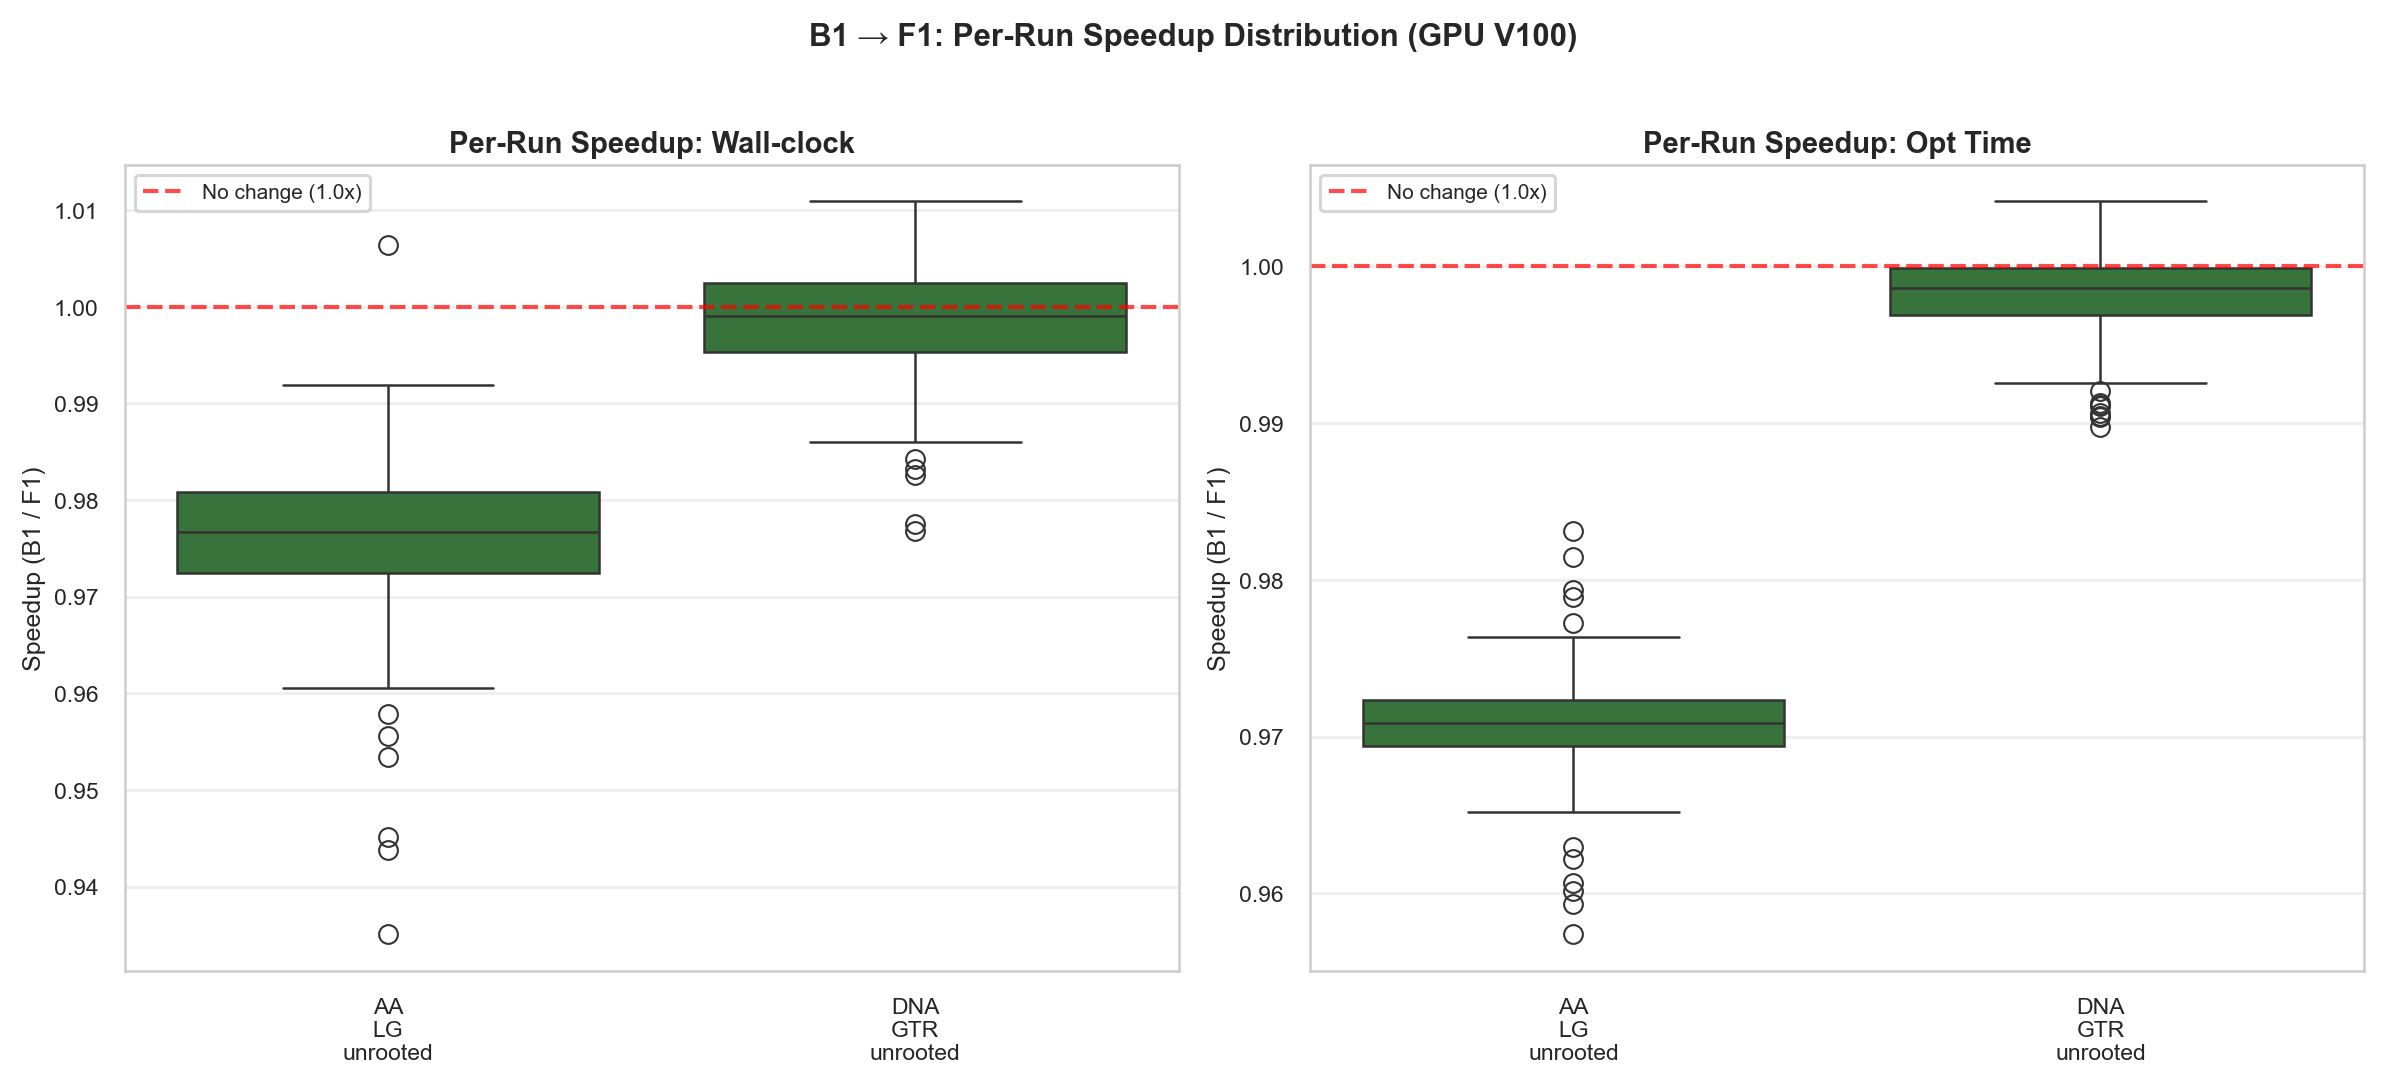

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

for ax, metric, title_suffix in [(ax1, 'wallclock_time', 'Wall-clock'), (ax2, 'opt_time', 'Opt Time')]:
    ratios_list = []
    combos = df_f1[['data_type','tree_type','model','backend']].drop_duplicates()

    for _, combo in combos.iterrows():
        dt, tt, model, backend = combo['data_type'], combo['tree_type'], combo['model'], combo['backend']
        for tree in sorted(df_f1[(df_f1['data_type']==dt) & (df_f1['model']==model)]['treefile'].unique()):
            for run in range(1, 11):
                bl_val = df_baseline[(df_baseline['data_type']==dt) & (df_baseline['tree_type']==tt) & 
                               (df_baseline['model']==model) & (df_baseline['backend']==backend) &
                               (df_baseline['treefile']==tree) & (df_baseline['run']==run)][metric]
                f1_val = df_f1[(df_f1['data_type']==dt) & (df_f1['tree_type']==tt) & 
                               (df_f1['model']==model) & (df_f1['backend']==backend) &
                               (df_f1['treefile']==tree) & (df_f1['run']==run)][metric]
                if len(bl_val) == 1 and len(f1_val) == 1:
                    ratio = bl_val.values[0] / f1_val.values[0]
                    ratios_list.append({
                        'combo': f'{dt}\n{model}\n{tt}',
                        'speedup': ratio
                    })

    df_ratios = pd.DataFrame(ratios_list)
    if not df_ratios.empty:
        sns.boxplot(data=df_ratios, x='combo', y='speedup', linewidth=1.2,
                    color='#2E7D32', ax=ax)
        ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, label='No change (1.0x)')
        ax.set_xlabel('')
        ax.set_ylabel(f'Speedup (B1 / F1)', fontsize=12)
        ax.set_title(f'Per-Run Speedup: {title_suffix}', fontsize=14, fontweight='bold')
        ax.grid(True, axis='y', alpha=0.3)
        ax.legend(fontsize=10)

plt.suptitle('B1 \u2192 F1: Per-Run Speedup Distribution (GPU V100)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{cwd}/comparison_speedup_distribution.png", bbox_inches='tight', dpi=300)
plt.show()

# 10. Correctness: Log-likelihood comparison

In [12]:
print("=" * 70)
print("Correctness: Log-likelihood comparison (B1 vs F1)")
print("=" * 70)

all_match = True
max_diff_overall = 0.0
combos = df_f1[['data_type','tree_type','model']].drop_duplicates()

for _, combo in combos.iterrows():
    dt, tt, model = combo['data_type'], combo['tree_type'], combo['model']
    for tree in sorted(df_f1[(df_f1['data_type']==dt) & (df_f1['model']==model)]['treefile'].unique()):
        bl_lls = sorted(df_baseline[(df_baseline['data_type']==dt) & (df_baseline['tree_type']==tt) & 
                           (df_baseline['model']==model) & (df_baseline['treefile']==tree)]['optimal_likelihood'].unique())
        f1_lls = sorted(df_f1[(df_f1['data_type']==dt) & (df_f1['tree_type']==tt) & 
                           (df_f1['model']==model) & (df_f1['treefile']==tree)]['optimal_likelihood'].unique())
        if set(bl_lls) != set(f1_lls):
            if len(bl_lls) == len(f1_lls):
                diffs = [abs(a - b) for a, b in zip(bl_lls, f1_lls)]
                max_d = max(diffs)
                max_diff_overall = max(max_diff_overall, max_d)
                print(f"  DIFF {dt}/{model}/{tt}/{tree}: max_diff={max_d:.6f}")
                if max_d > 0.01:
                    all_match = False
                    print(f"    B1: {bl_lls}")
                    print(f"    F1: {f1_lls}")
            else:
                print(f"  MISMATCH {dt}/{model}/{tt}/{tree}: B1 has {len(bl_lls)} unique, F1 has {len(f1_lls)} unique")
                all_match = False

if all_match and max_diff_overall == 0.0:
    print("  All log-likelihoods match exactly (0.0 diff) across all trees and runs")
    print("  Correctness: VERIFIED")
elif all_match:
    print(f"  Max LL diff: {max_diff_overall:.6f} (within tolerance)")
    print("  Correctness: VERIFIED (minor floating-point differences)")
else:
    print(f"  WARNING: Significant LL mismatches detected! Max diff: {max_diff_overall:.6f}")

Correctness: Log-likelihood comparison (B1 vs F1)
  All log-likelihoods match exactly (0.0 diff) across all trees and runs
  Correctness: VERIFIED


# 11. Comparison with CPU-48 baseline (overall standing)

In [13]:
# Try to load CPU-48 results from the B1 baseline (which should have CPU results)
cpu_combos = df_baseline[df_baseline['backend'] == 'CPU_48cores'][['data_type','tree_type','model']].drop_duplicates()

if len(cpu_combos) > 0:
    print("=" * 70)
    print("GPU vs CPU-48 comparison (F1 GPU vs CPU-48 from baseline)")
    print("=" * 70)
    
    for _, combo in cpu_combos.iterrows():
        dt, tt, model = combo['data_type'], combo['tree_type'], combo['model']
        cpu_med = df_baseline[(df_baseline['data_type']==dt) & (df_baseline['tree_type']==tt) & 
                              (df_baseline['model']==model) & (df_baseline['backend']=='CPU_48cores')]['opt_time'].median()
        f1_gpu_med = df_f1[(df_f1['data_type']==dt) & (df_f1['tree_type']==tt) & 
                           (df_f1['model']==model) & (df_f1['backend']=='GPU_V100')]['opt_time'].median()
        if cpu_med > 0 and f1_gpu_med > 0:
            ratio = f1_gpu_med / cpu_med
            print(f"  {dt}/{model} ({tt}): GPU={f1_gpu_med:.2f}s, CPU-48={cpu_med:.2f}s, ratio={ratio:.2f}x")
            if ratio < 1:
                print(f"    >>> GPU is {1/ratio:.2f}x FASTER than CPU-48! <<<")
            else:
                print(f"    GPU is {ratio:.2f}x slower than CPU-48")
else:
    print("No CPU-48 results found in baseline for comparison.")

No CPU-48 results found in baseline for comparison.


# 12. Summary

In [14]:
print("=" * 70)
print("SUMMARY: F1 — computeLikelihoodFromBuffer for OpenACC")
print("=" * 70)
print()
print("Change: Eliminated redundant full likelihood evaluations during")
print("        branch length optimization by:")
print("  1. Making derivative kernel store _pattern_lh[p] as side-effect")
print("  2. New computeLikelihoodFromBufferOpenACC() does cheap GPU reduction")
print("  3. Previously: computeLikelihoodFromBufferPointer = NULL")
print("     → every convergence check called FULL computeLikelihoodBranch")
print("     → ~197 redundant evaluations per round × 3-4 rounds")
print()

combos = df_f1[['data_type','tree_type','model','backend']].drop_duplicates()
print(f"{'Model':<20} {'B1 wc_med':>12} {'F1 wc_med':>12} {'WC change':>10} | {'B1 opt_med':>12} {'F1 opt_med':>12} {'Opt change':>10}")
print(f"{'-'*20} {'-'*12} {'-'*12} {'-'*10} | {'-'*12} {'-'*12} {'-'*10}")

for _, combo in combos.iterrows():
    dt, tt, model, backend = combo['data_type'], combo['tree_type'], combo['model'], combo['backend']
    bl_wc_med = df_baseline[(df_baseline['data_type']==dt) & (df_baseline['tree_type']==tt) & 
                   (df_baseline['model']==model) & (df_baseline['backend']==backend)]['wallclock_time'].median()
    f1_wc_med = df_f1[(df_f1['data_type']==dt) & (df_f1['tree_type']==tt) & 
                   (df_f1['model']==model) & (df_f1['backend']==backend)]['wallclock_time'].median()
    bl_opt_med = df_baseline[(df_baseline['data_type']==dt) & (df_baseline['tree_type']==tt) & 
                   (df_baseline['model']==model) & (df_baseline['backend']==backend)]['opt_time'].median()
    f1_opt_med = df_f1[(df_f1['data_type']==dt) & (df_f1['tree_type']==tt) & 
                   (df_f1['model']==model) & (df_f1['backend']==backend)]['opt_time'].median()
    wc_pct = (f1_wc_med - bl_wc_med) / bl_wc_med * 100
    opt_pct = (f1_opt_med - bl_opt_med) / bl_opt_med * 100
    label = f"{dt}/{model} ({tt})"
    print(f"{label:<20} {bl_wc_med:>12.3f} {f1_wc_med:>12.3f} {wc_pct:>+9.1f}% | {bl_opt_med:>12.3f} {f1_opt_med:>12.3f} {opt_pct:>+9.1f}%")

print()
print("Expected: 8-25% speedup from eliminating ~600-800 redundant full") 
print("          likelihood evaluations per branch length optimization.")

SUMMARY: F1 — computeLikelihoodFromBuffer for OpenACC

Change: Eliminated redundant full likelihood evaluations during
        branch length optimization by:
  1. Making derivative kernel store _pattern_lh[p] as side-effect
  2. New computeLikelihoodFromBufferOpenACC() does cheap GPU reduction
  3. Previously: computeLikelihoodFromBufferPointer = NULL
     → every convergence check called FULL computeLikelihoodBranch
     → ~197 redundant evaluations per round × 3-4 rounds

Model                   B1 wc_med    F1 wc_med  WC change |   B1 opt_med   F1 opt_med Opt change
-------------------- ------------ ------------ ---------- | ------------ ------------ ----------
AA/LG (unrooted)           18.239       18.697      +2.5% |       15.388       15.838      +2.9%
DNA/GTR (unrooted)         17.242       17.248      +0.0% |       14.490       14.508      +0.1%

Expected: 8-25% speedup from eliminating ~600-800 redundant full
          likelihood evaluations per branch length optimization.
